# 1st Kr NEXT-100 data look

## Run 15502 - compare Kr maps (LT map, 3D, LT - unique)

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

## Configuration

In [2]:
import re
import glob
from collections import namedtuple

import sys
pypaths= ("/Users/hernando/work/investigacion/NEXT/software/nextana",
         "/Users/hernando/work/investigacion/NEXT/software/hipy",
         "/Users/hernando/work/investigacion/NEXT/software/IC")
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [3]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [4]:
from invisible_cities.io.dst_io import load_dst, load_dsts

In [5]:
import hipy.utils        as ut
import hipy.histos       as histos
import hipy.pltext       as pltext
import hipy.profile      as prof

import nana.kr.krana    as krana
import nana.kr.kr100ana as krn100
import nana.kr.krmap    as krtool

#import nana.bclouds.bclouds      as bc
#import hipy.hfit         as hfit
from invisible_cities.io.dst_io import load_dst, load_dsts
#import invisible_cities.io.dst_io as dio

In [6]:
pltext.style()

import warnings
warnings.filterwarnings('ignore')

import time
print(' Last revision ', time.asctime())

 Last revision  Fri Aug  1 16:06:55 2025


## Import Data

In [11]:
run_number = 15502
path_data = '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/' 
path_run =  f'{run_number}/hdf5/prod/v2.3.1/20250512/sophronia/trigger1/'
#path_run  = '14862/sophronia'
#path_run = '/250107_4bar/data/kdst'
#path_run = '/250203_4bar'


from os import listdir

filenames = listdir(path_data + path_run)
filenames.sort()
filenames = [path_data + path_run + '/' + ifile for ifile in filenames if ifile.find('.h5')>0]
print('number of files :', len(filenames))
print('fist files: ', filenames[0], filenames[-1])


number of files : 7
fist files:  /Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15502/hdf5/prod/v2.3.1/20250512/sophronia/trigger1//ldc1.h5 /Users/hernando/work/investigacion/NEXT/data/NEXT100/data/15502/hdf5/prod/v2.3.1/20250512/sophronia/trigger1//ldc7.h5


In [13]:
kdst = load_dsts(filenames, "DST", "Events")
#kdst = load_dst(filenames[0], "DST", "Events")

## Prepare Data

In [14]:
kdst = krn100.df_extend(kdst)
#kdst = kdst.rename(columns = {'S2e' : 'energy', 'X' : 'x', 'Y' : 'y', 'Z' : 'dt', 'Zrms': 'dtrms',
#                              'DT' : 'dtime', 'R' : 'r'})

## Standard selection

In [15]:
kdst_, effs    = krn100.kdst_select(kdst)

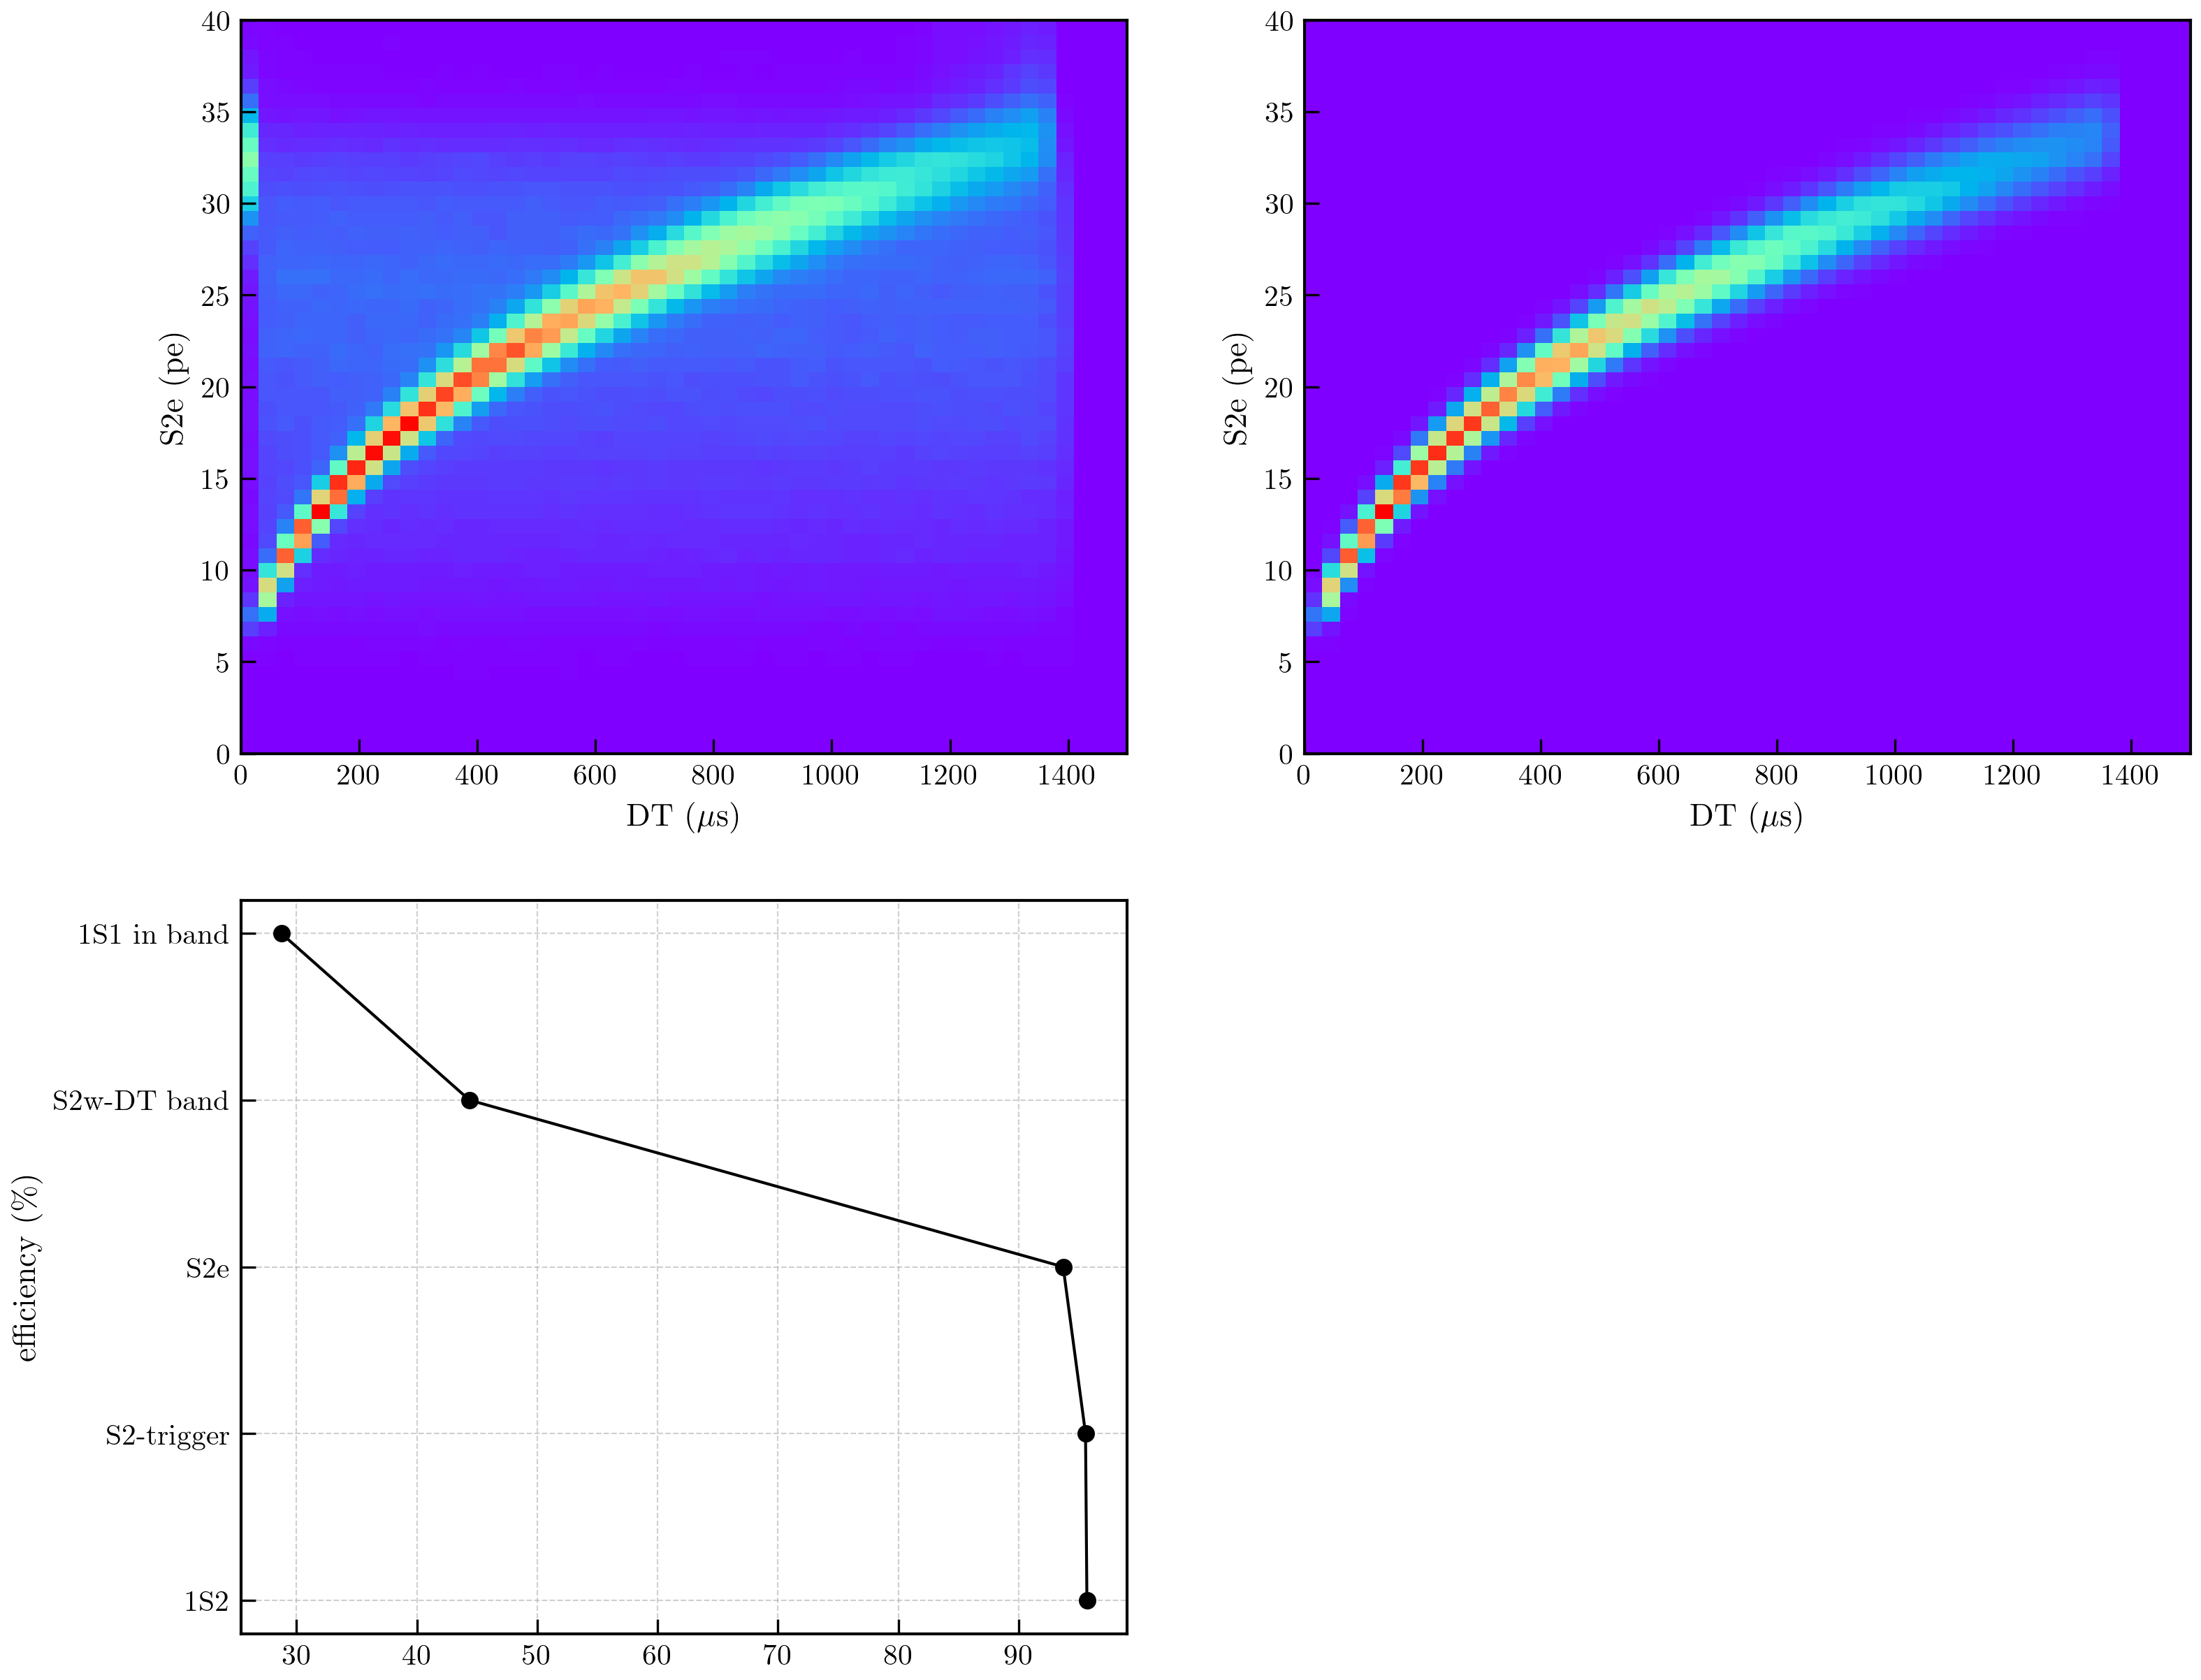

In [16]:
cv = pltext.canvas(4, 2)
cv(3);
names, vals = [x[0] for x in effs], [100.*x[1] for x in effs]
plt.plot(vals, names, marker = "o", color = 'black', lw =1); plt.ylabel("efficiency (\%)")
cv(1); plt.hist2d(kdst.DT, kdst.S2w, 50, ((0, 1500), (0, 40))); 
plt.xlabel(r'DT ($\mu$s)'), plt.ylabel('S2e (pe)');
cv(2); plt.hist2d(kdst_.DT, kdst_.S2w, 50, ((0, 1500), (0, 40))); 
plt.xlabel(r'DT ($\mu$s)'), plt.ylabel('S2e (pe)');

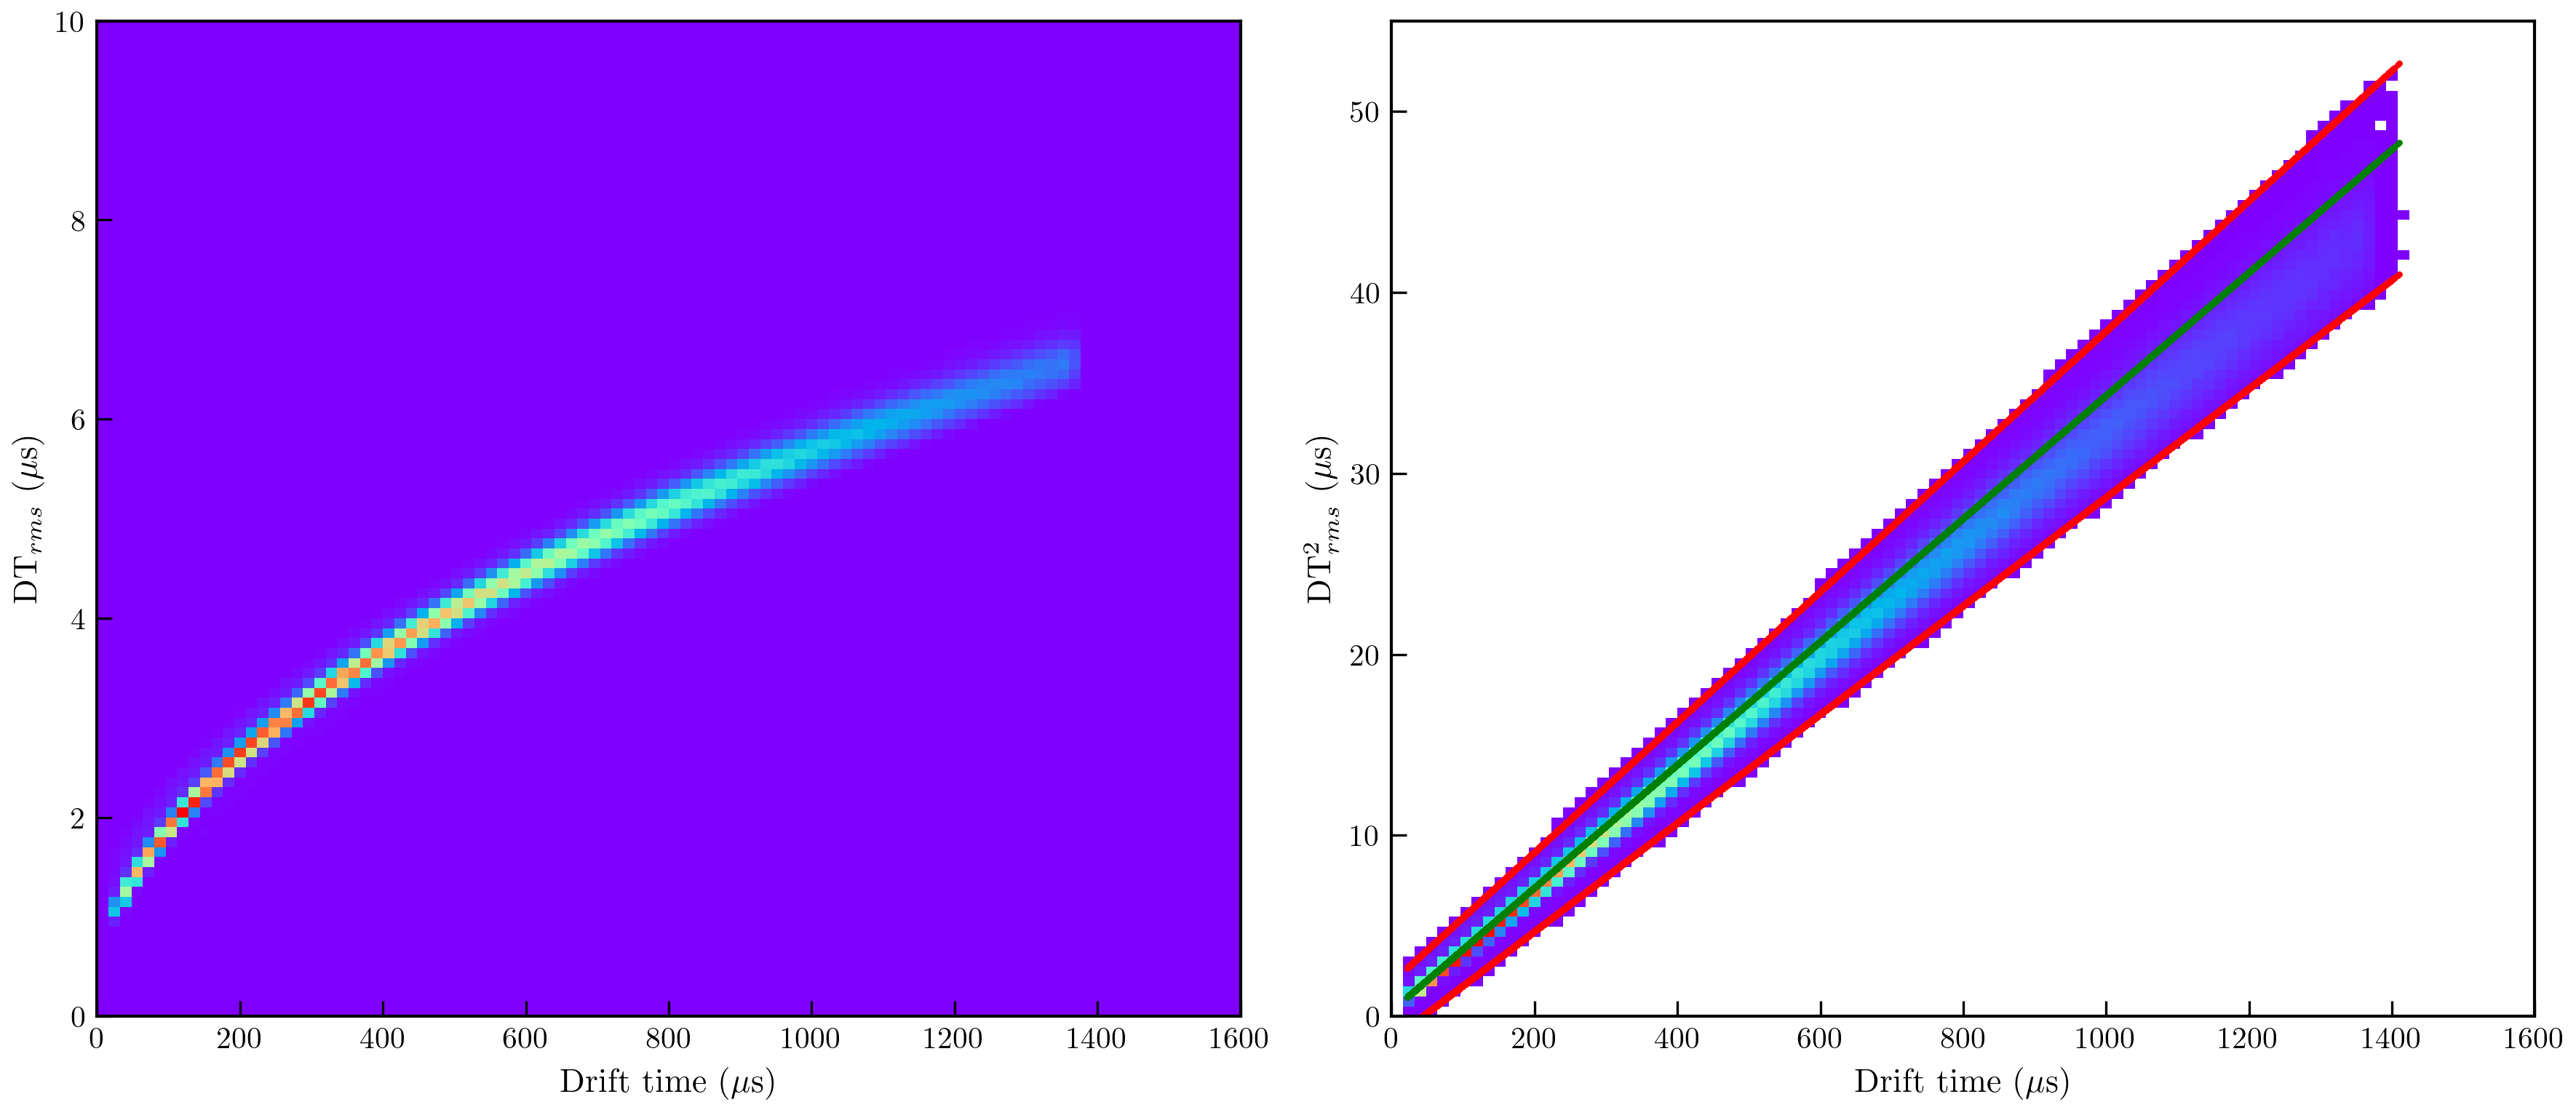

In [17]:
#krn100.monitor_S1S2(kdst_)
#krn100.monitor_S2(kdst_)
krn100.monitor_S2s_dtime(kdst_)
#krn100.monitor_lifetime(kdst_)

## Fidutal selection

In [18]:
df = kdst_
sels = {}
sels['R']        = ut.in_range(df.R  , (0., 500.))
sels['DT']       = ut.in_range(df.DT , (0., 2000.))
sels['S2e']      = ut.in_range(df.S2e, (0e3, 9e3))
sels['fidutial'] = (sels['R']) & (sels['DT']) & (sels['S2e'])

## Clean data : fidutial and residuals

In [19]:
counts_min = 40
pitch      = 5.00
xmin       = -489.825
#xbins      = np.arange(xmin-pitch, -xmin + pitch, pitch)
xbins      = np.arange(xmin, -xmin + pitch, pitch)
bins       = (xbins, xbins) 
print('number of bins ', len(xbins), ', range : ', xbins[0], ', ', xbins[-1])

number of bins  197 , range :  -489.825 ,  490.175


In [20]:
#df     = kdst_
sel    = sels['fidutial']
coors  = df[sel].X, df[sel].Y
energy = df[sel].S2e
dtime  = df[sel].DT

In [21]:
min_sigma = 0.9
dt0       = 0 # compute the map in the EL
sel       = sels['fidutial']
krf, res_1, usel = krtool.krmap_clean((df[sel].X, df[sel].Y), df.DT[sel], df[sel].S2e,
                                       bins = bins, dt0 = dt0, plot = False)

sigma 0.94 done  True  eff 97.85


In [22]:
cdf = df[sel][usel]

## LT unique study

In [23]:
rmax       = 350.
k2d, res_2 = krtool.krmap_ltunique((cdf.X, cdf.Y), cdf.DT, cdf.S2e, 
                                   bins = bins, rmax = rmax, boost = True)

1.0011633895950551 36475.964332320305


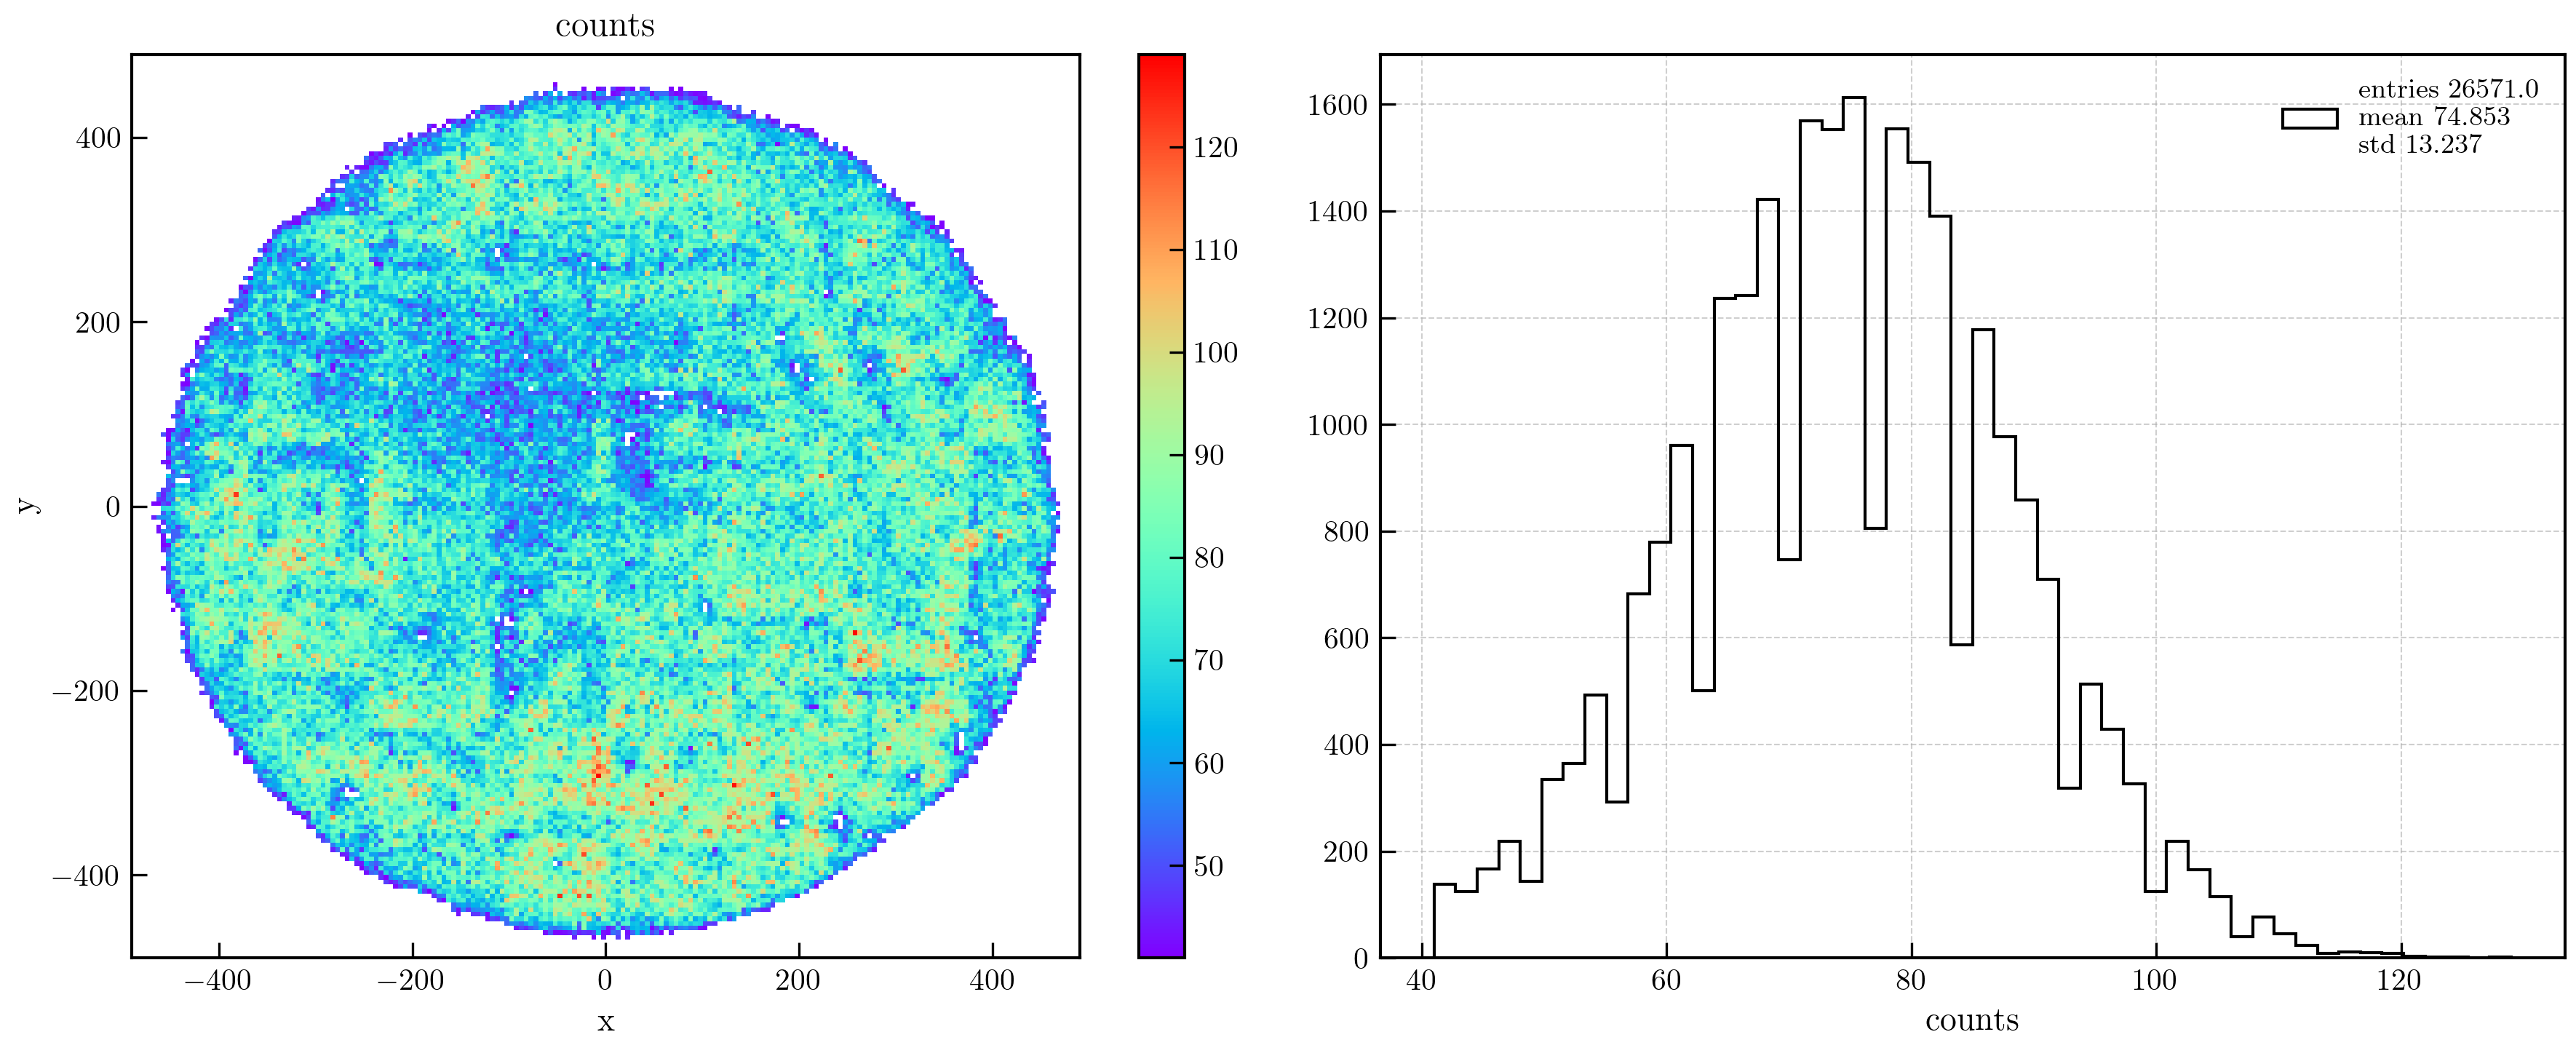

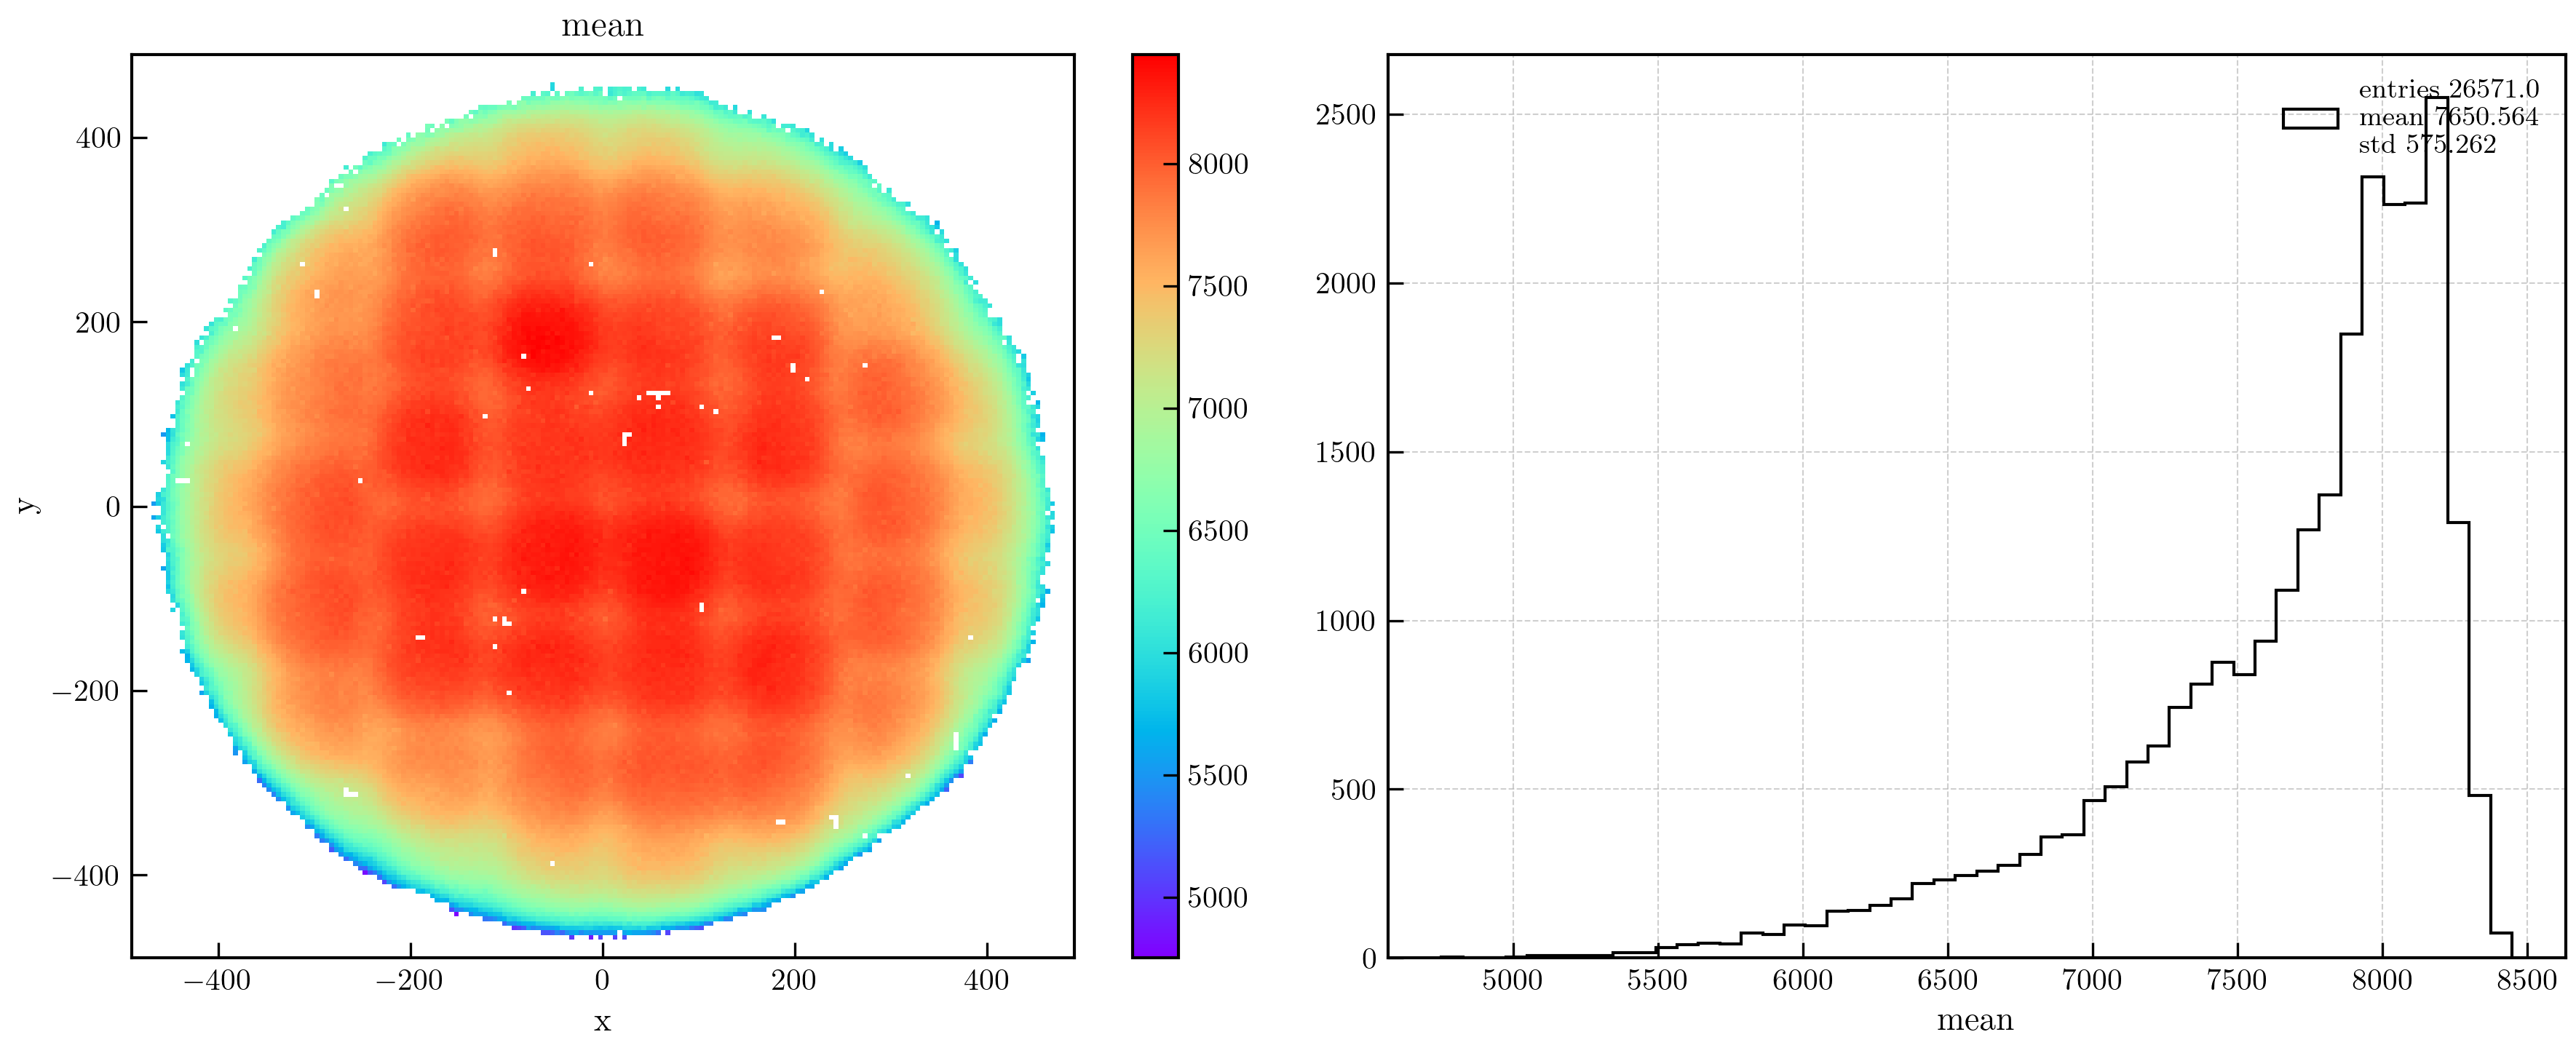

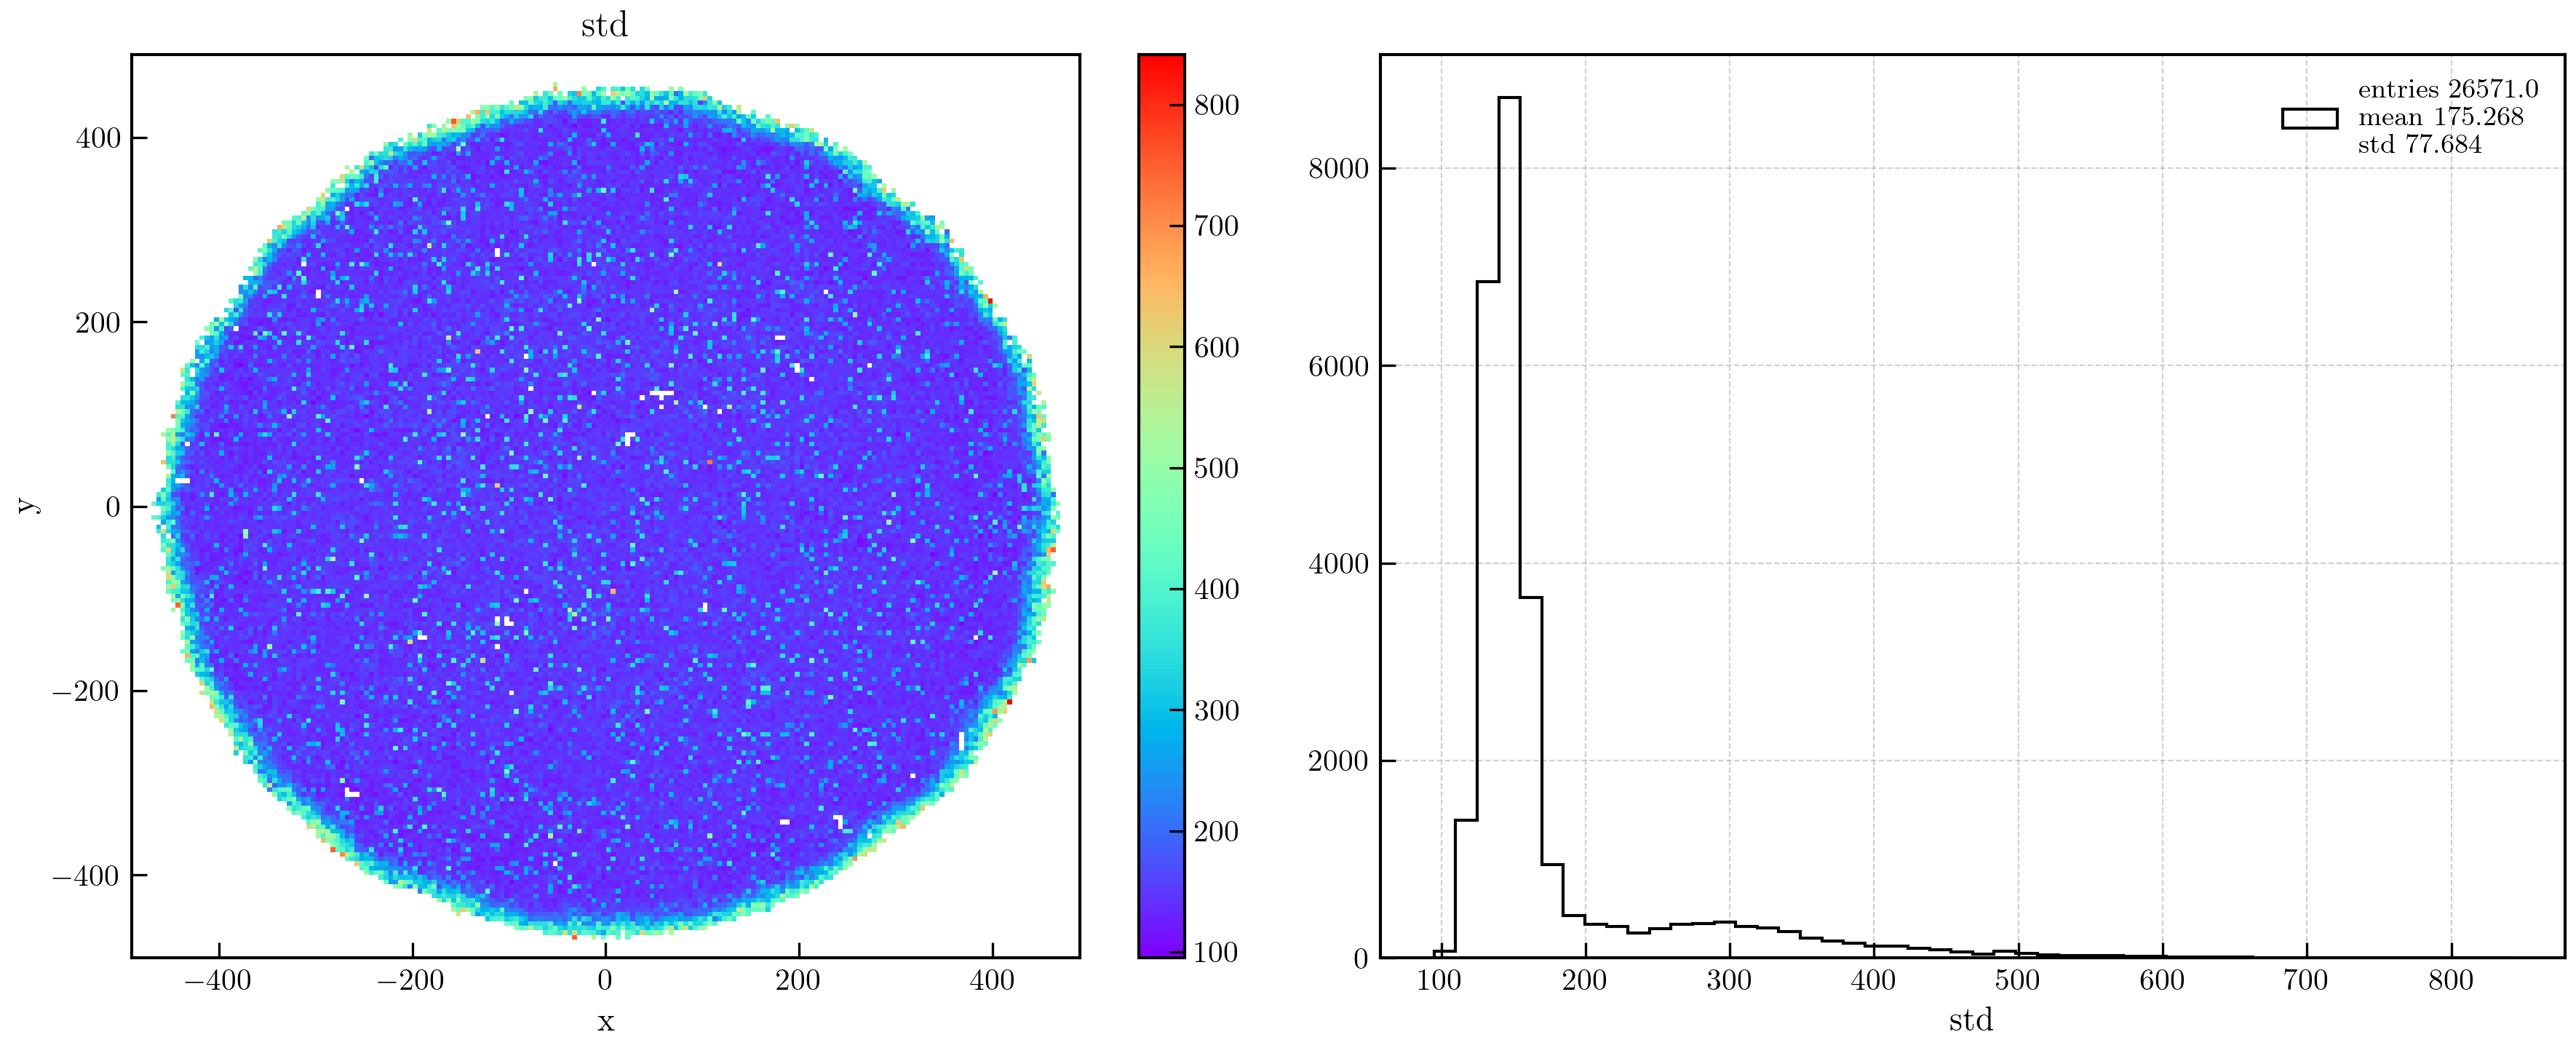

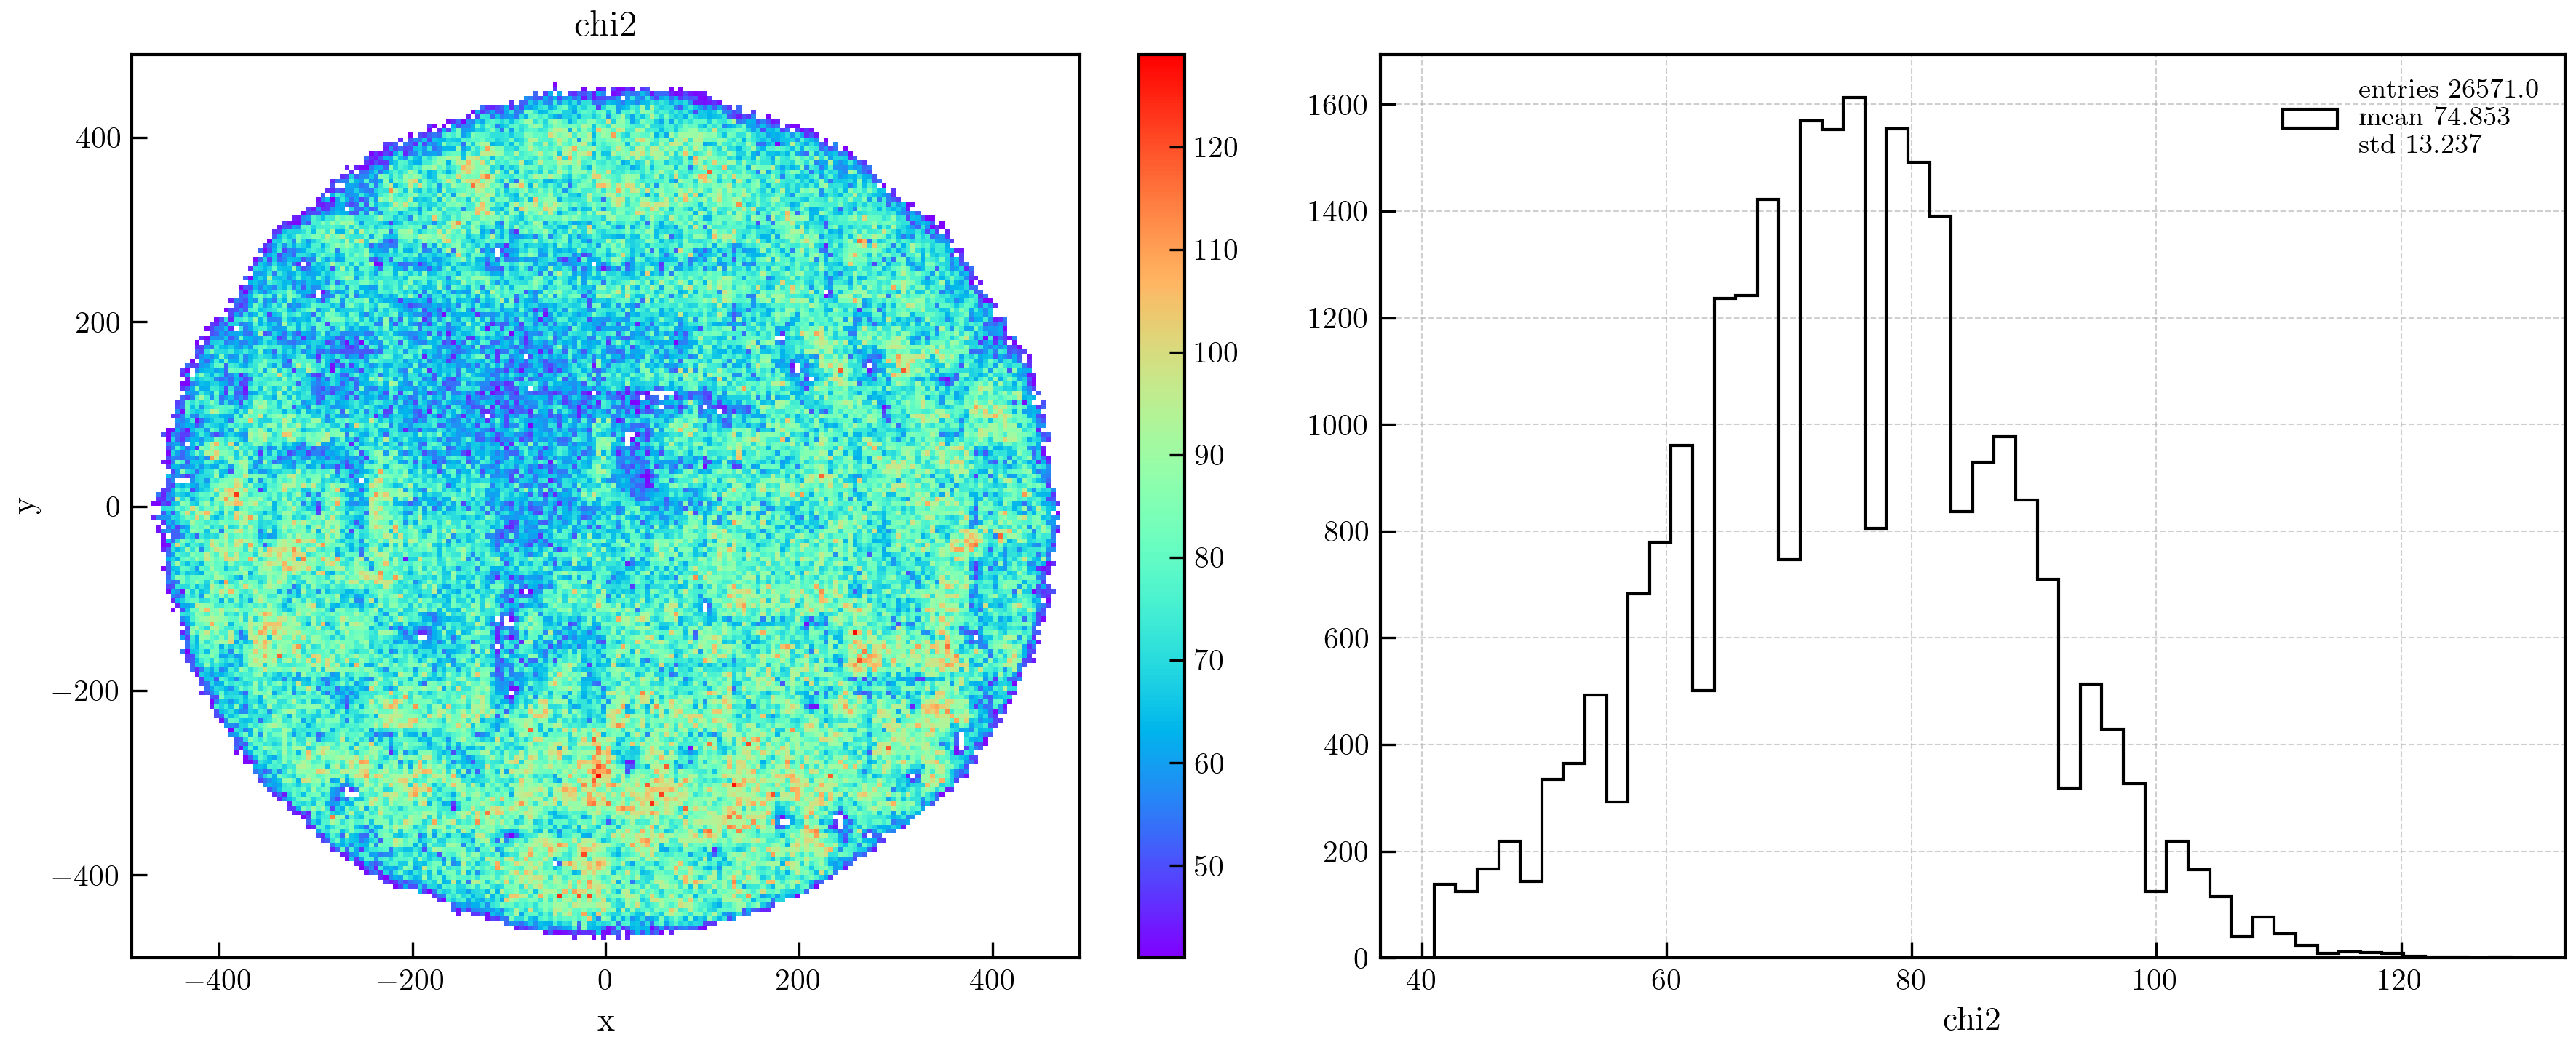

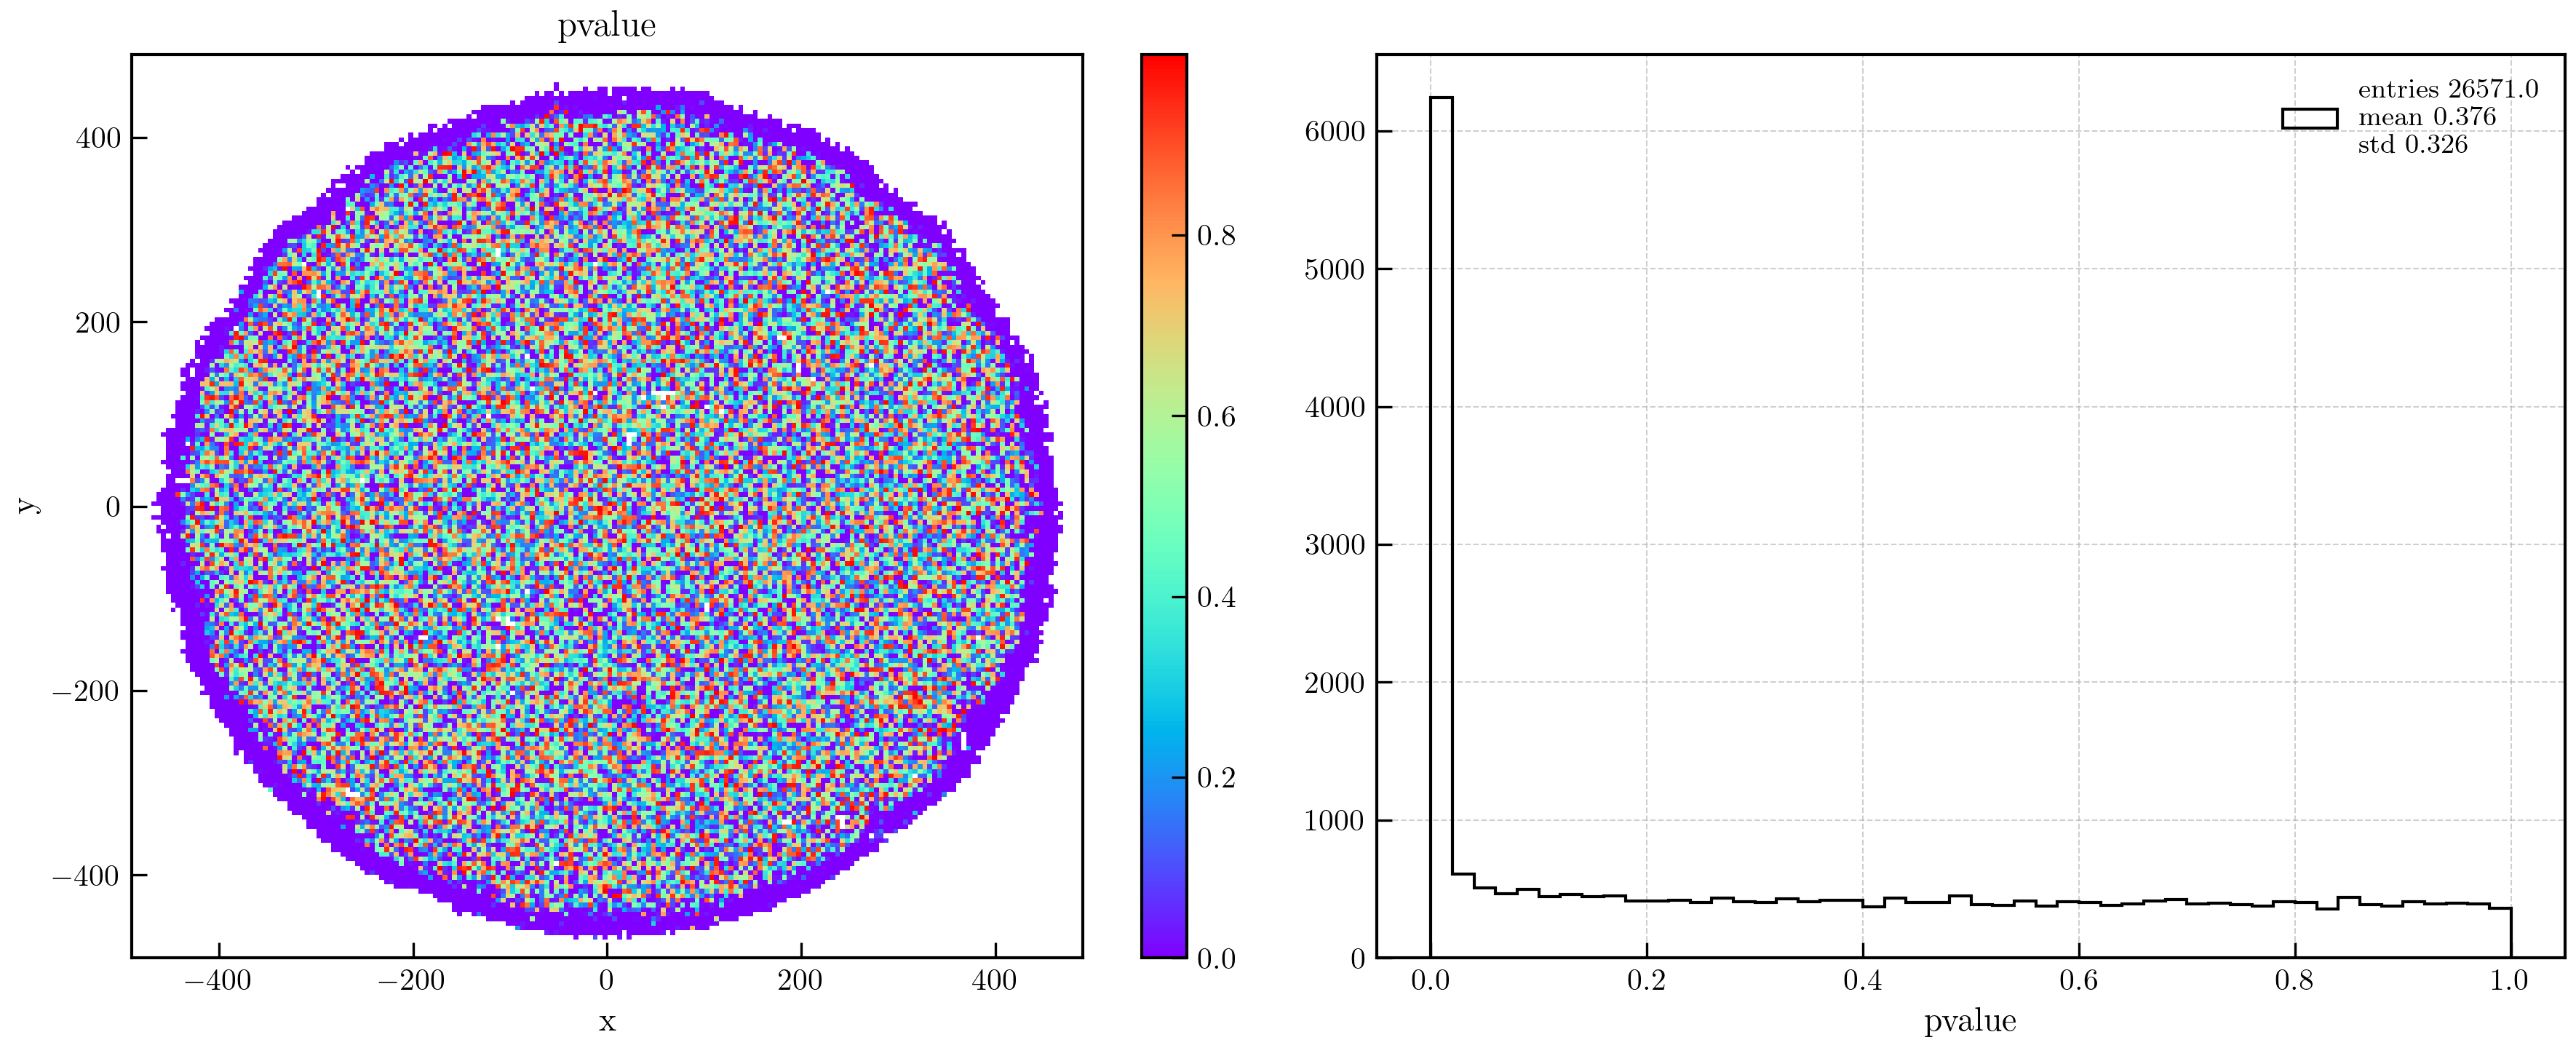

In [24]:
print(k2d.eref, k2d.lt)
prof.plot_profile(k2d.prof, stats = ('counts', 'mean', 'std', 'chi2', 'pvalue'));

### LT vs Radius

In [25]:
r      = np.sqrt(cdf.X**2 + cdf.Y**2)
dtime  = cdf.DT
ene    = prof.profile_scale((cdf.X, cdf.Y), cdf.S2e, k2d.prof, scale = 1.)
ene    = cdf.S2e 
rs     = np.linspace(50, 450, 42)
erefs, uerefs = [], []
lts, ults = [], []
for rmax in rs:
    rsel = r < rmax
    cc = krtool.lifetime(dtime[rsel], ene[rsel])
    erefs.append(cc[0]); uerefs.append(cc[1])
    lts.append(cc[2]); ults.append(cc[3])

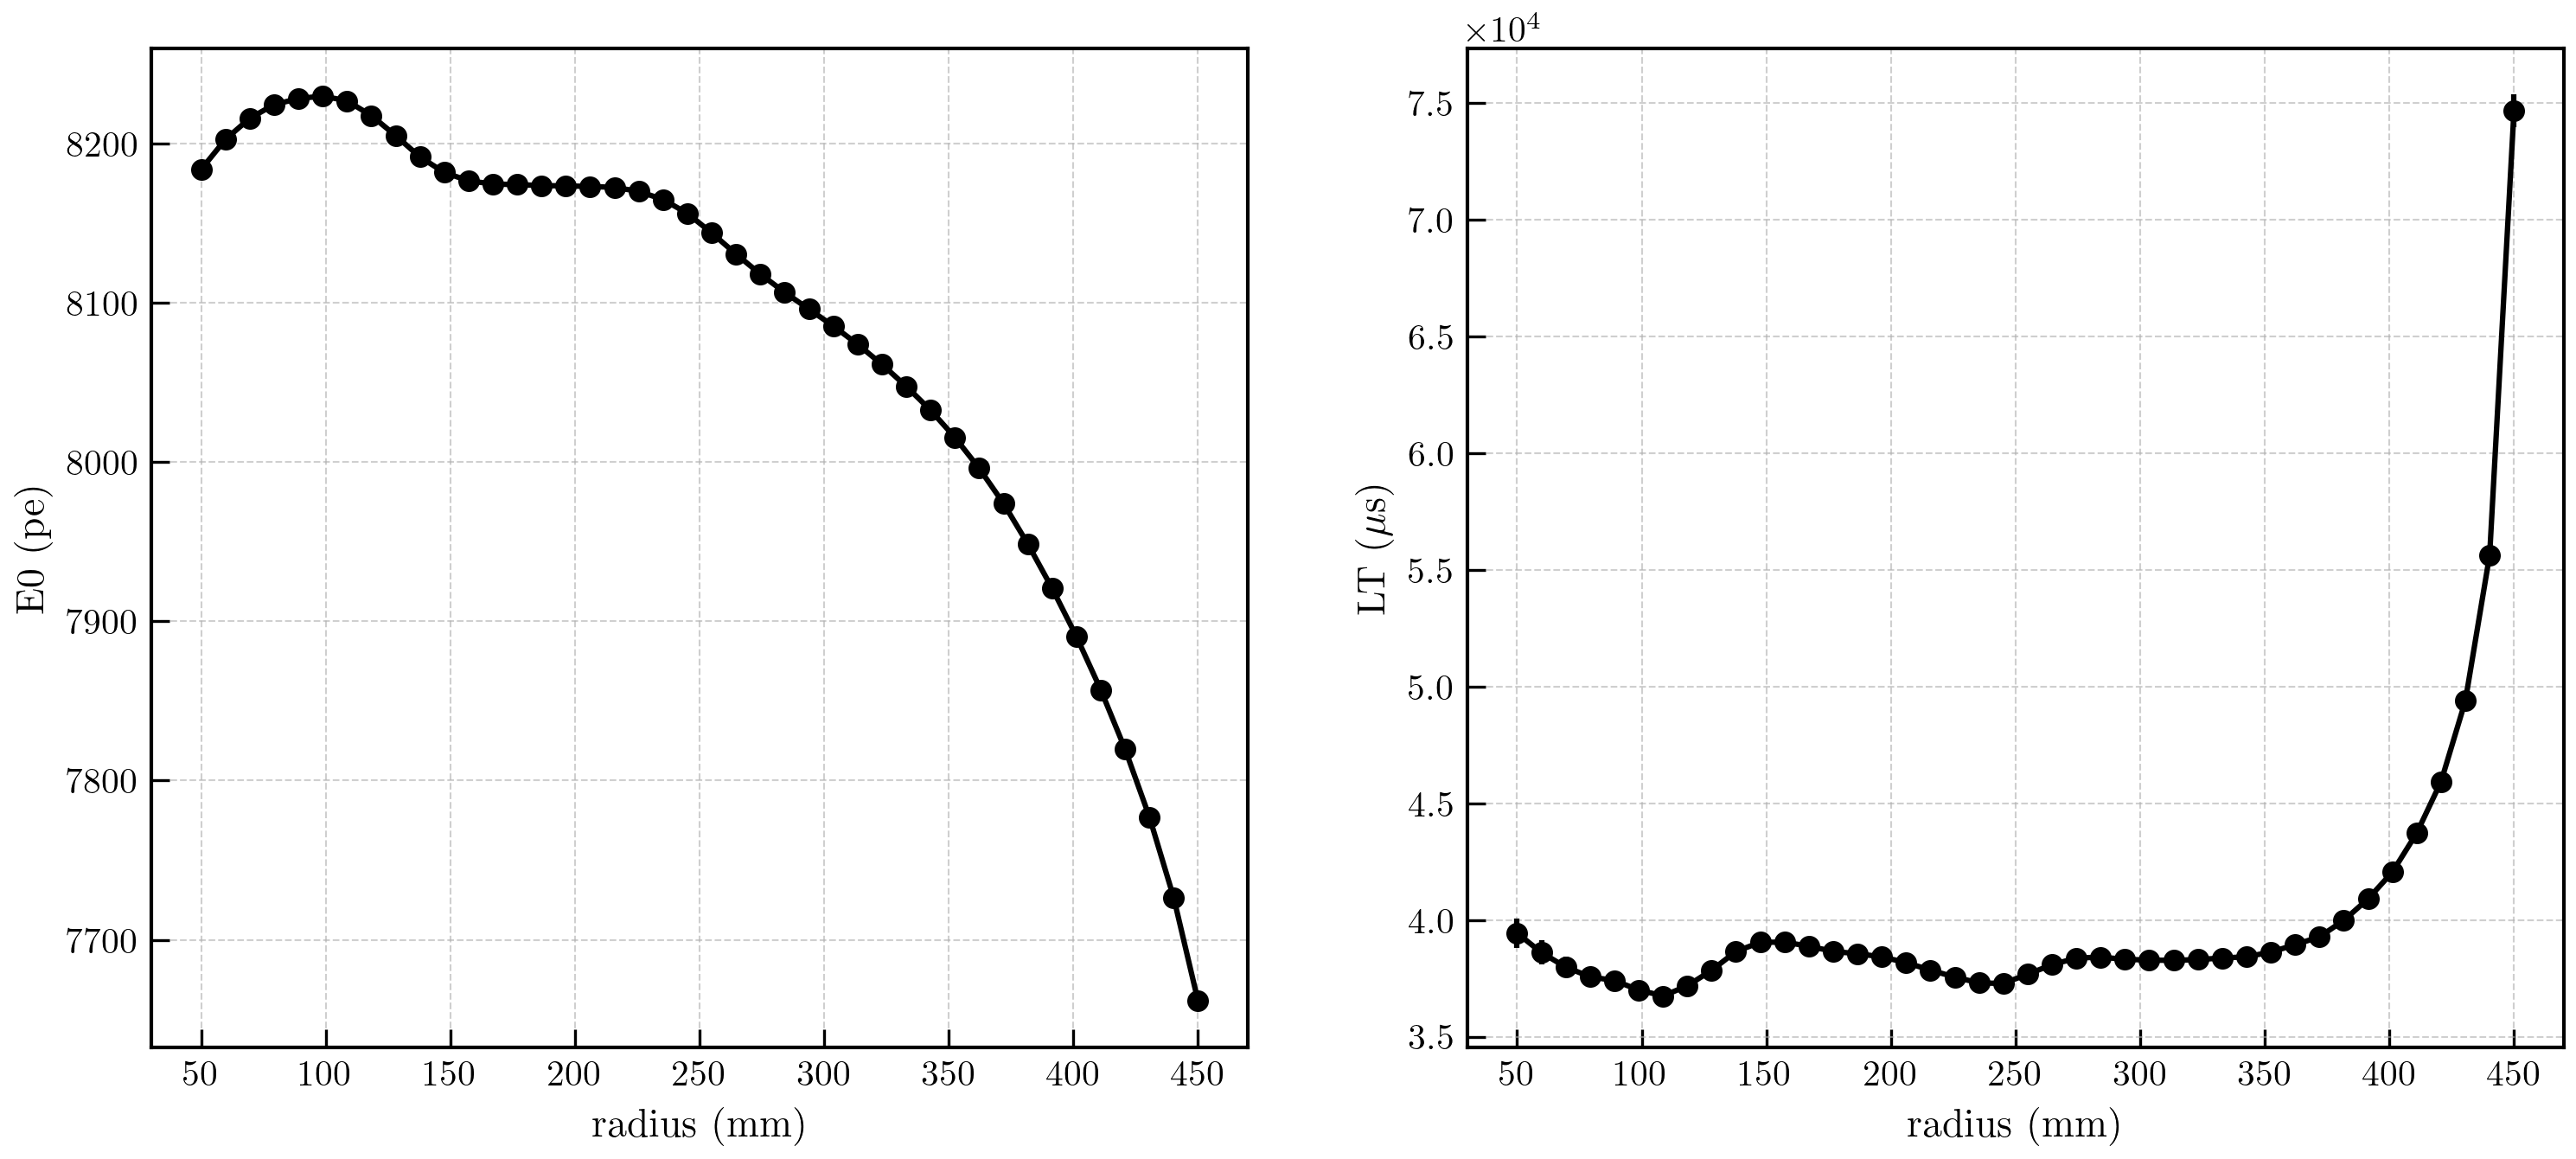

In [ ]:
cv = pltext.canvas(2, 2)
cv(1)
plt.errorbar(rs, erefs, yerr = uerefs, fmt = 'o', ls = '-'); plt.xlabel('radius (mm)'); plt.ylabel('E0 (pe)');
cv(2)
plt.errorbar(rs, lts, yerr = ults, fmt='o', ls = '-'); plt.xlabel('radius (mm)'); plt.ylabel(r'LT ($\mu$s)');
#cv(3)
#plt.errorbar(erefs, lts, yerr = ults, fmt='o', ls = '-'); plt.xlabel('E0 (ps)'); plt.ylabel(r'LT ($\mu$s)');
#cv(4)
#dedt = np.array(erefs)/np.array(lts)
#plt.errorbar(rs, dedt, fmt = 'o', ls = '-');
#plt.xlabel('radius (mm)'); plt.ylabel(r'de/dt (pe/$\mu$s)');
plt.tight_layout();


In [28]:
r      = np.sqrt(cdf.X**2 + cdf.Y**2)
dtime  = cdf.DT
ene    = prof.profile_scale((cdf.X, cdf.Y), cdf.S2e, k2d.prof, scale = 1.)
#ene    = cdf.S2e 
rs     = np.linspace(50, 450, 42)
erefs, uerefs = [], []
lts, ults = [], []
for rmax in rs:
    rsel = r < rmax
    cc = krtool.lifetime(dtime[rsel], ene[rsel])
    erefs.append(cc[0]); uerefs.append(cc[1])
    lts.append(cc[2]); ults.append(cc[3])

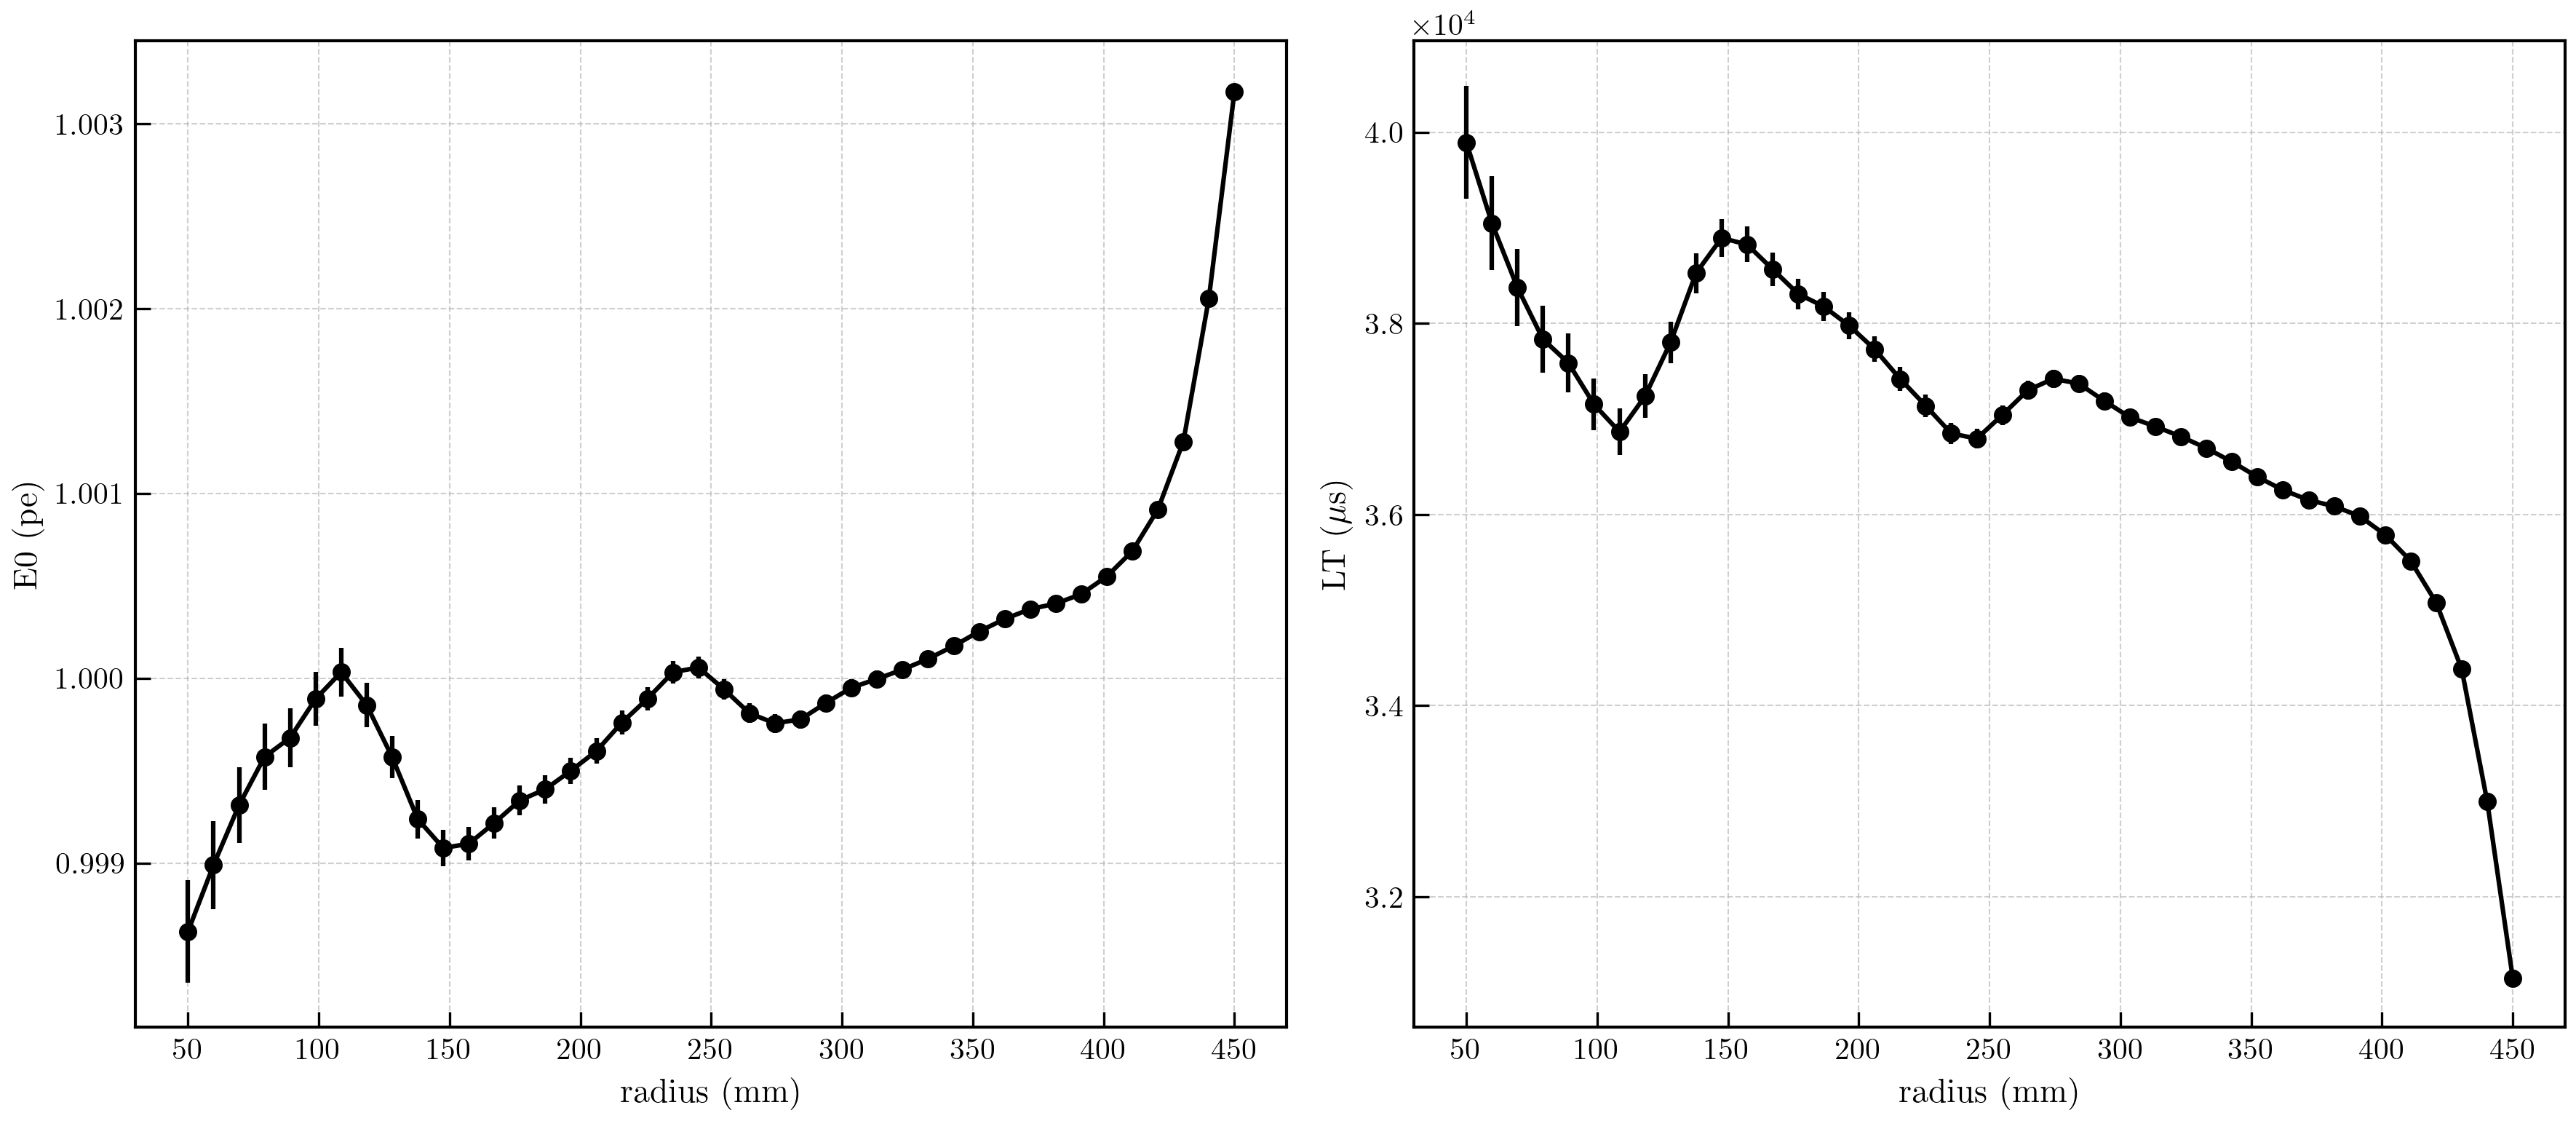

In [31]:
cv = pltext.canvas(4, 2)
cv(1)
plt.errorbar(rs, erefs, yerr = uerefs, fmt = 'o', ls = '-'); plt.xlabel('radius (mm)'); plt.ylabel('E0 (pe)');
cv(2)
plt.errorbar(rs, lts, yerr = ults, fmt='o', ls = '-'); plt.xlabel('radius (mm)'); plt.ylabel(r'LT ($\mu$s)');
#cv(3)
#plt.errorbar(erefs, lts, yerr = ults, fmt='o', ls = '-'); plt.xlabel('E0 (ps)'); plt.ylabel(r'LT ($\mu$s)');
#cv(4)
#dedt = np.array(erefs)/np.array(lts)
#plt.errorbar(rs, dedt, fmt = 'o', ls = '-');
#plt.xlabel('radius (mm)'); plt.ylabel(r'de/dt (pe/$\mu$s)');
plt.tight_layout();